In [36]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score

sys.path.append(str(Path().resolve().parent))

from src.data import get_data
from src.features import generate_features
from src.backtest import backtest, results_table, optimize, optimize_assets, fit_strategy
from src.strategy import (
    logistic_strategy, momentum_strategy, momentum_volatility_strategy, mean_reversion_strategy, momentum_trend_strategy, momentum_voluratio_strategy
)
from src.visualization import plot_performance
from src.ml import build_ml_dataset, train_logistic

## Experiments

In [37]:
windows = range(1, 51)
strategies = [
    ('Momentum', momentum_strategy, 'mom', None, None),
    ('Mean Reversion', mean_reversion_strategy, 'mr', range(2, 100, 2), None),
    ("Momentum + Trend Strength", momentum_trend_strategy, "mo_tr", None, None),
    ("Momentum + Rolling Volatility", momentum_volatility_strategy, "mo_vo", range(2, 100, 2), None),
    ("Momentum + Volume Ratio", momentum_voluratio_strategy, "mo_vr", None, None),
    ("Logistic Regression", logistic_strategy, "lr", None, train_logistic)
]

In [38]:
assets = ['GOOG']

#assets = ['DOCS','IBM','BE','XOM','GLD','JNJ','SCCO','ECL','JPM','META']

[*********************100%***********************]  1 of 1 completed

GOOG
Momentum
Market Sharpe Ratio: 0.5804
Best Momentum Strategy window: 40
Best Sharpe ratio: 0.7844

Mean Reversion


Market Sharpe Ratio: 0.5804
Best Mean Reversion Strategy window: 24
Best threshold: 6%
Best Sharpe ratio: 0.8760

Momentum + Trend Strength
Market Sharpe Ratio: 0.5804
Best Momentum + Trend Strength Strategy window: 34
Best Sharpe ratio: 0.7880

Momentum + Rolling Volatility
Market Sharpe Ratio: 0.5804
Best Momentum + Rolling Volatility Strategy window: 40
Best threshold: 2%
Best Sharpe ratio: 0.8102

Momentum + Volume Ratio
Market Sharpe Ratio: 0.5804
Best Momentum + Volume Ratio Strategy window: 16
Best Sharpe ratio: 0.3897

Logistic Regression
Training ML model...
Logistic Regression model trained and tested.

Training Performance


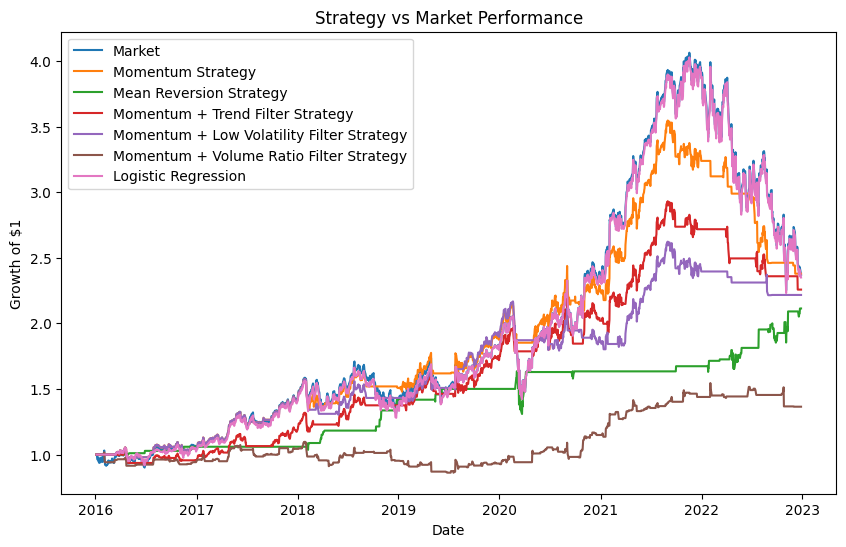

Testing Performance


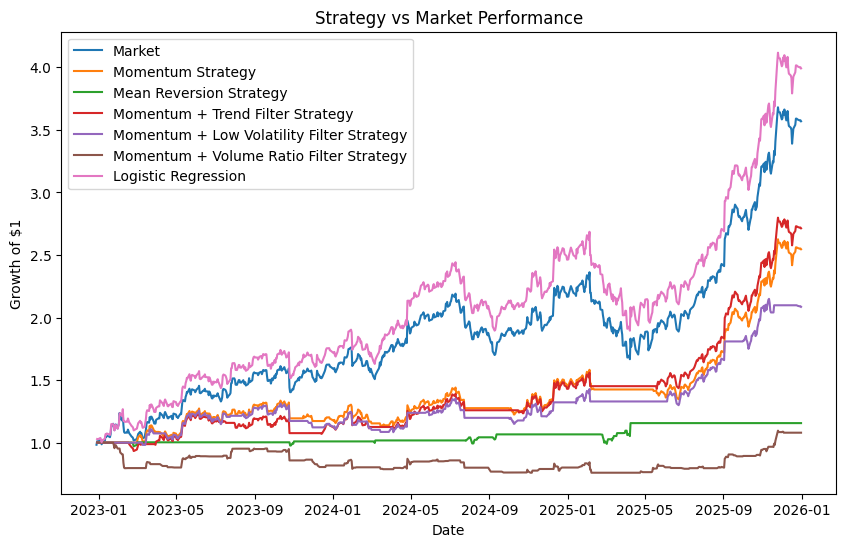


Training Results
                        Strategy    Sharpe  Volatility    Max DD  \
0                         Market  0.580450    0.281458 -0.446018   
1                       Momentum  0.784428    0.178720 -0.329206   
2                 Mean Reversion  0.876042    0.132397 -0.198948   
3      Momentum + Trend Strength  0.788048    0.165461 -0.229795   
4  Momentum + Rolling Volatility  0.810179    0.155828 -0.173476   
5        Momentum + Volume Ratio  0.389655    0.139212 -0.214673   
6            Logistic Regression  0.580808    0.276934 -0.446018   

   Signal Accuracy  Signal Precision  Signal Recall  
0              NaN               NaN            NaN  
1         0.523024          0.549500       0.638186  
2         0.475839          0.612069       0.074895  
3         0.514497          0.549266       0.552743  
4         0.515634          0.551836       0.539030  
5         0.490620          0.565327       0.237342  
6         0.536669          0.539095       0.967300  

Test

In [39]:
optimize_assets(
    assets,
    "2016-01-01",
    "2026-01-01",
    strategies,
    windows=range(2, 50, 2),    
)

## Analysis

In [40]:
strategy = [
    'Momentum',
    'Mean Reversion',
    'Momentum + Trend Strength',
    'Momentum + Rolling Volatility',
    'Momentum + Volume Ratio',
    'Logistic Regression'
]
featureversion = [None, 'v1']
df = pd.read_csv("../outputs/experiment_results.csv")
df = df[df['Strategy'].isin(strategy)]
df = df[df['Feature Set'].isin(featureversion)]
df

,Asset,Strategy,Feature Set,Window,Threshold,Train Sharpe,Train Volatility,Train Max DD,Train Signal Accuracy,Train Signal Precision,Train Signal Recall,Test Sharpe,Test Volatility,Test Max DD,Test Signal Accuracy,Test Signal Precision,Test Signal Recall
0,AAPL,Momentum,NaN,14.0,NaN,1.416952,0.199519,-0.313157,0.525867,0.543907,0.651288,1.212668,0.174526,-0.169209,0.532450,0.565310,0.637681
1,AAPL,Mean Reversion,NaN,4.0,2.0,1.028301,0.136398,-0.118219,0.484935,0.585526,0.095494,-0.209006,0.118274,-0.235419,0.450331,0.489796,0.057971
2,AAPL,Momentum + Trend Strength,NaN,10.0,NaN,1.197057,0.151061,-0.144578,0.509380,0.545575,0.443133,1.026926,0.120937,-0.123670,0.490066,0.546032,0.415459
3,AAPL,Momentum + Rolling Volatility,NaN,14.0,2.0,1.686844,0.157121,-0.118903,0.522456,0.552154,0.522532,1.001642,0.163049,-0.170032,0.509934,0.551643,0.567633
4,AAPL,Momentum + Volume Ratio,NaN,20.0,NaN,1.230180,0.135403,-0.141400,0.495736,0.555283,0.242489,0.782793,0.118371,-0.145055,0.470199,0.541667,0.219807
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,META,Mean Reversion,NaN,14.0,2.0,0.832727,0.232620,-0.272569,0.512791,0.574684,0.247817,0.333164,0.200296,-0.217802,0.478146,0.523490,0.194514
100,META,Momentum + Trend Strength,NaN,2.0,NaN,0.511245,0.171388,-0.208577,0.491188,0.518650,0.318777,0.923767,0.240679,-0.326528,0.492715,0.527439,0.431421
101,META,Momentum + Rolling Volatility,NaN,48.0,4.0,0.561760,0.219496,-0.245076,0.509380,0.525407,0.598253,0.967129,0.296195,-0.267216,0.500662,0.522727,0.688279
102,META,Momentum + Volume Ratio,NaN,36.0,NaN,0.044754,0.152552,-0.303578,0.481524,0.505988,0.184498,0.734640,0.202133,-0.195728,0.468874,0.500000,0.229426


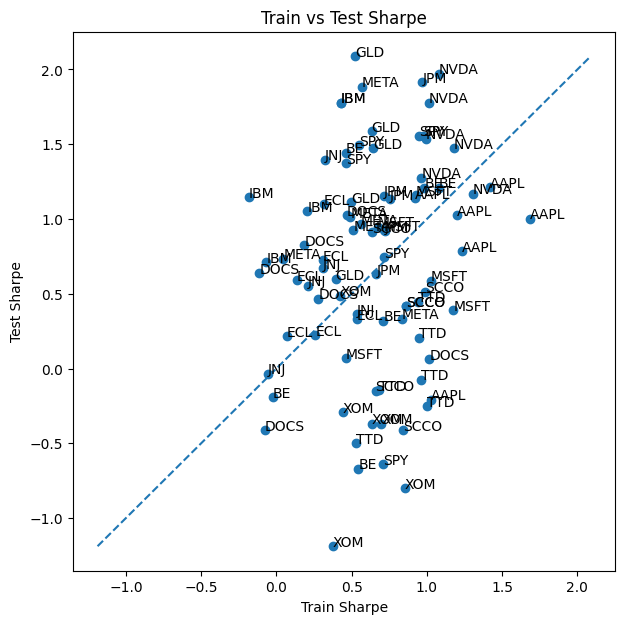

In [41]:
plt.figure(figsize=(7,7))

plt.scatter(df["Train Sharpe"], df["Test Sharpe"])

lims = [
    min(df["Train Sharpe"].min(), df["Test Sharpe"].min()),
    max(df["Train Sharpe"].max(), df["Test Sharpe"].max())
]

plt.plot(lims, lims, "--")

for _, row in df.iterrows():
    plt.text(
        row["Train Sharpe"],
        row["Test Sharpe"],
        row["Asset"]
    )

plt.xlabel("Train Sharpe")
plt.ylabel("Test Sharpe")
plt.title("Train vs Test Sharpe")

plt.show()

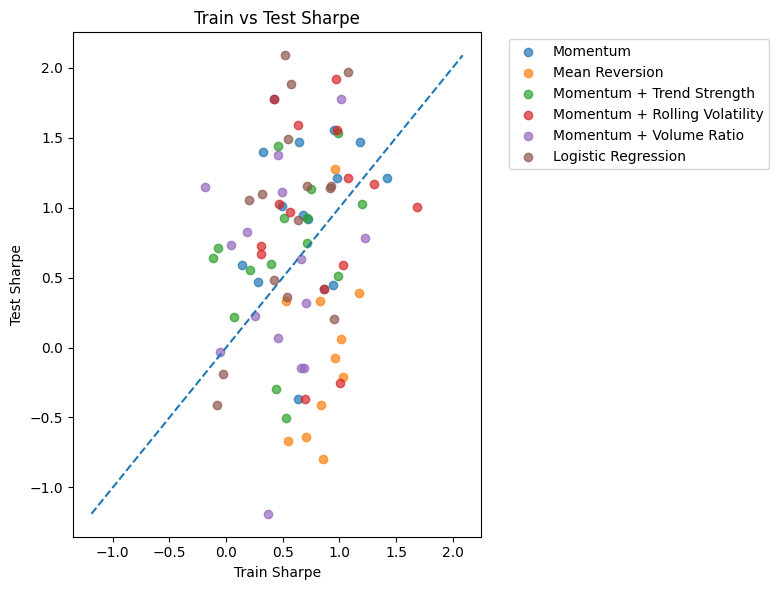

In [42]:
plt.figure(figsize=(8,6))

for strategy in df["Strategy"].unique():

    subset = df[df["Strategy"] == strategy]

    plt.scatter(
        subset["Train Sharpe"],
        subset["Test Sharpe"],
        label=strategy,
        alpha=0.7
    )

lims = [
    min(df["Train Sharpe"].min(), df["Test Sharpe"].min()),
    max(df["Train Sharpe"].max(), df["Test Sharpe"].max())
]

plt.plot(lims, lims, "--")

plt.xlabel("Train Sharpe")
plt.ylabel("Test Sharpe")
plt.title("Train vs Test Sharpe")
plt.legend(bbox_to_anchor=(1.05,1))
plt.tight_layout()

plt.show()

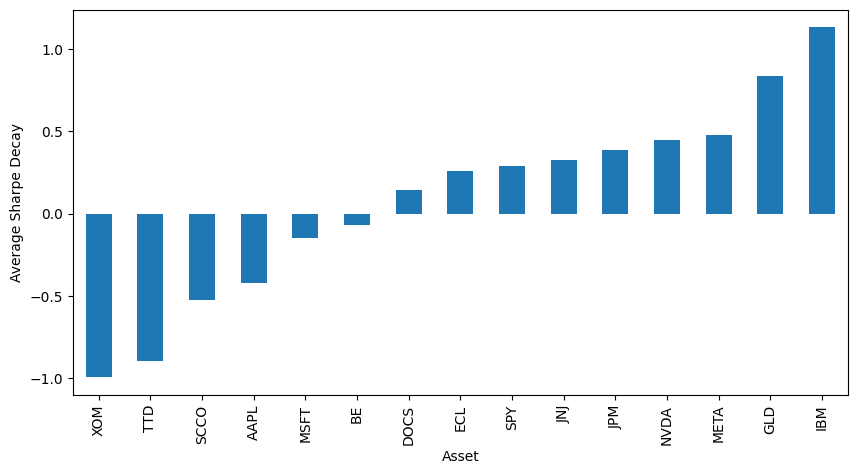

In [43]:
df["Decay"] = (
    df["Test Sharpe"] -
    df["Train Sharpe"]
)

decay = (
    df.groupby("Asset")["Decay"]
      .mean()
      .sort_values()
)

decay.plot.bar(figsize=(10,5))

plt.ylabel("Average Sharpe Decay")

plt.show()

In [44]:
summary = (
    df.groupby("Asset")
      .agg({
          "Train Sharpe":"mean",
          "Test Sharpe":"mean",
          "Train Volatility":"mean",
          "Test Volatility":"mean",
          "Train Max DD":"mean",
          "Test Max DD":"mean",
          "Test Signal Accuracy":"mean",
          "Test Signal Precision":"mean",
          "Test Signal Recall":"mean"
      })
      .sort_values(
          "Test Sharpe",
          ascending=False
      )
)

summary

,Train Sharpe,Test Sharpe,Train Volatility,Test Volatility,Train Max DD,Test Max DD,Test Signal Accuracy,Test Signal Precision,Test Signal Recall
Asset,,,,,,,,,
NVDA,1.087961,1.534348,0.316856,0.332032,-0.378158,-0.259712,0.498234,0.610941,0.511962
GLD,0.543989,1.371317,0.086358,0.111428,-0.141083,-0.088135,0.501545,0.465618,0.514613
IBM,0.253776,1.293372,0.145309,0.140886,-0.260691,-0.124152,0.509934,0.485381,0.456556
JPM,0.757106,1.150412,0.155652,0.120386,-0.200924,-0.125835,0.506843,0.484237,0.477414
SPY,0.726323,1.014523,0.100589,0.080530,-0.146777,-0.074945,0.507726,0.481809,0.529002
META,0.501679,0.975717,0.219200,0.252561,-0.298631,-0.259552,0.496909,0.523322,0.513300
AAPL,1.246377,0.825518,0.179731,0.158630,-0.203926,-0.196287,0.500442,0.540587,0.483092
MSFT,0.829519,0.680052,0.179241,0.153898,-0.232214,-0.174194,0.483223,0.515930,0.484069
JNJ,0.332088,0.590378,0.111835,0.102834,-0.194287,-0.134602,0.514570,0.455591,0.437817


<Figure size 1000x500 with 0 Axes>

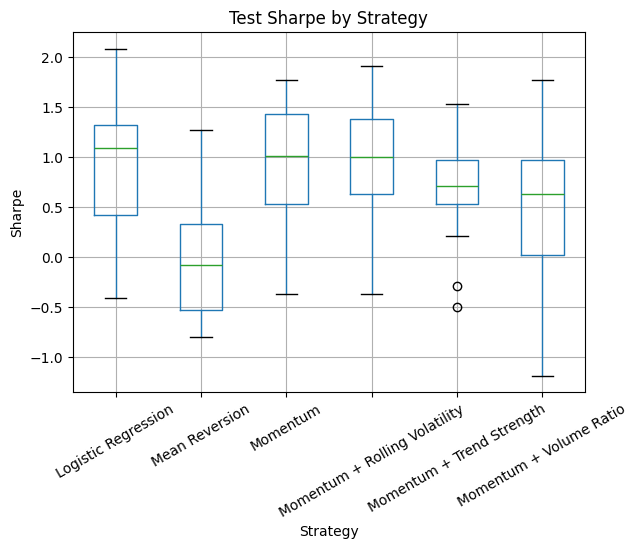

In [45]:
plt.figure(figsize=(10,5))

df.boxplot(
    column="Test Sharpe",
    by="Strategy",
    rot=30
)

plt.title("Test Sharpe by Strategy")
plt.suptitle("")
plt.ylabel("Sharpe")

plt.show()

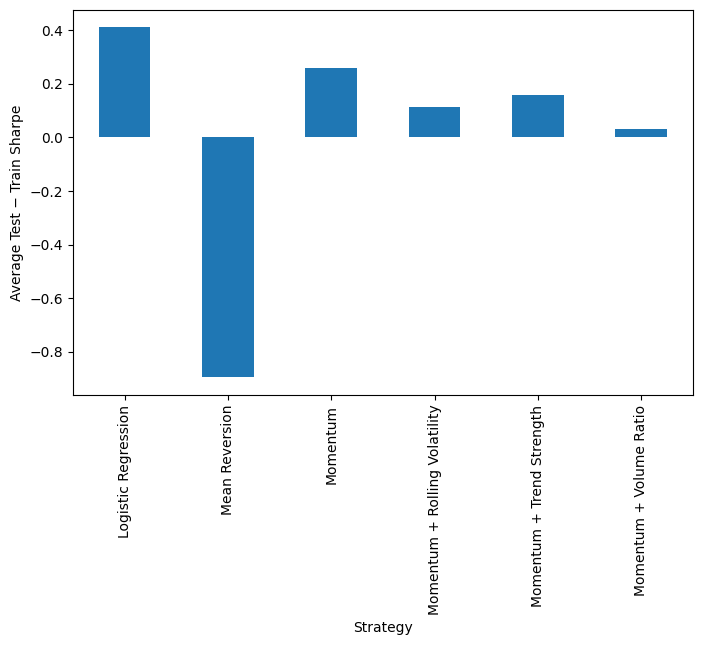

In [46]:
df["Sharpe Decay"] = (
    df["Test Sharpe"] -
    df["Train Sharpe"]
)

decay = (
    df.groupby("Strategy")["Sharpe Decay"]
      .mean()
)

decay.plot.bar(figsize=(8,5))

plt.ylabel("Average Test − Train Sharpe")

plt.show()

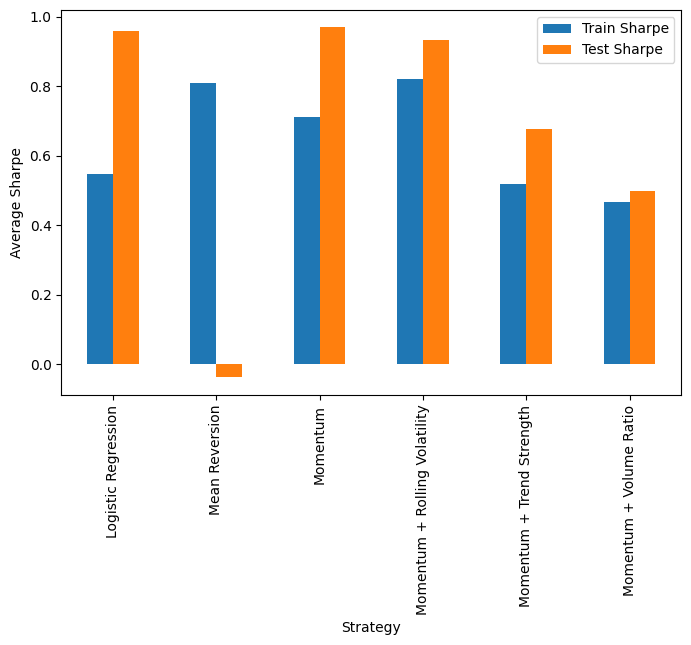

In [47]:
summary = (
    df.groupby("Strategy")
      [["Train Sharpe","Test Sharpe"]]
      .mean()
)

summary.plot.bar(figsize=(8,5))

plt.ylabel("Average Sharpe")
plt.show()

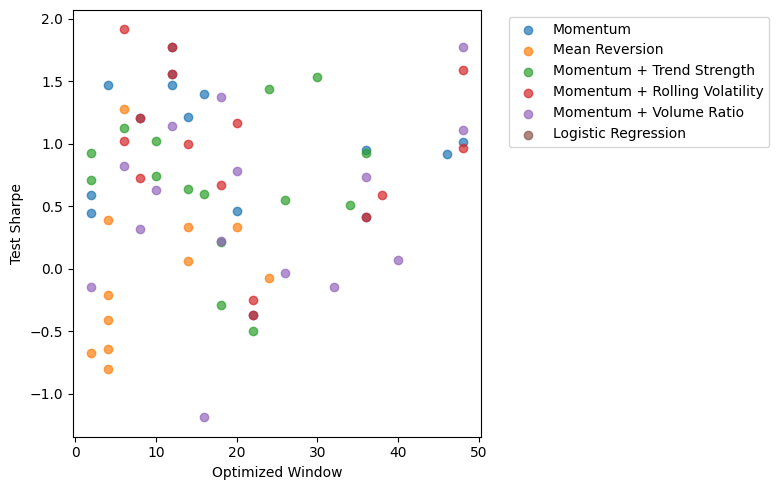

In [48]:
plt.figure(figsize=(8,5))

for strategy in df["Strategy"].unique():

    subset = df[df["Strategy"] == strategy]

    plt.scatter(
        subset["Window"],
        subset["Test Sharpe"],
        label=strategy,
        alpha=0.7
    )

plt.xlabel("Optimized Window")
plt.ylabel("Test Sharpe")

plt.legend(
    bbox_to_anchor=(1.05,1)
)

plt.tight_layout()
plt.show()

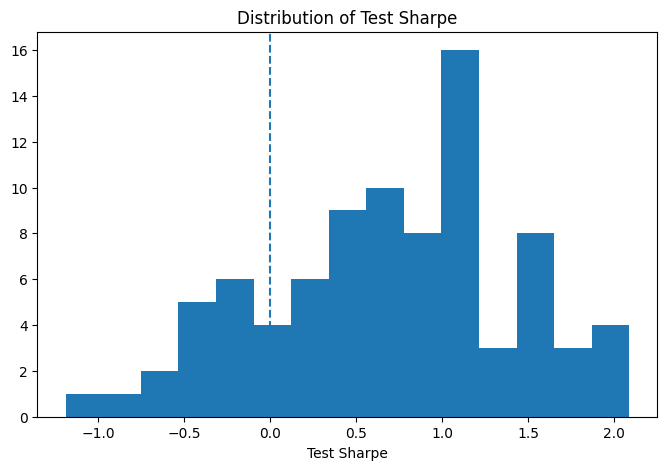

In [49]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Test Sharpe"],
    bins=15
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Test Sharpe")
plt.title("Distribution of Test Sharpe")

plt.show()

In [50]:
metrics = df[[
    "Train Sharpe",
    "Train Volatility",
    "Train Max DD",
    "Train Signal Accuracy",
    "Train Signal Precision",
    "Train Signal Recall",
    "Test Sharpe",
    "Test Volatility",
    "Test Max DD",
    "Test Signal Accuracy",
    "Test Signal Precision",
    "Test Signal Recall"
]]

metrics.corr()

,Train Sharpe,Train Volatility,Train Max DD,Train Signal Accuracy,Train Signal Precision,Train Signal Recall,Test Sharpe,Test Volatility,Test Max DD,Test Signal Accuracy,Test Signal Precision,Test Signal Recall
Train Sharpe,1.000000,0.229836,0.038145,0.148487,0.136581,0.160496,0.166702,0.130647,-0.150931,-0.012824,-0.009816,0.101353
Train Volatility,0.229836,1.000000,-0.801220,0.367676,-0.335667,0.312216,0.057435,0.910201,-0.850393,0.222729,0.222120,0.318904
Train Max DD,0.038145,-0.801220,1.000000,-0.401329,0.556141,-0.509799,-0.135290,-0.726935,0.768573,-0.361151,-0.410662,-0.502306
Train Signal Accuracy,0.148487,0.367676,-0.401329,1.000000,-0.180599,0.637869,0.218342,0.324060,-0.281918,0.543534,0.190675,0.610492
Train Signal Precision,0.136581,-0.335667,0.556141,-0.180599,1.000000,-0.457123,-0.349398,-0.449445,0.427117,-0.379918,-0.747540,-0.487707
Train Signal Recall,0.160496,0.312216,-0.509799,0.637869,-0.457123,1.000000,0.524543,0.295350,-0.313321,0.772642,0.422765,0.972805
Test Sharpe,0.166702,0.057435,-0.135290,0.218342,-0.349398,0.524543,1.000000,0.217317,0.173033,0.650984,0.564438,0.592185
Test Volatility,0.130647,0.910201,-0.726935,0.324060,-0.449445,0.295350,0.217317,1.000000,-0.783273,0.271866,0.302326,0.350474
Test Max DD,-0.150931,-0.850393,0.768573,-0.281918,0.427117,-0.313321,0.173033,-0.783273,1.000000,-0.145184,-0.250574,-0.311543
Test Signal Accuracy,-0.012824,0.222729,-0.361151,0.543534,-0.379918,0.772642,0.650984,0.271866,-0.145184,1.000000,0.432985,0.841130


In [51]:
df["Sharpe Ratio"] = np.where(
    df["Train Sharpe"] != 0,
    df["Test Sharpe"] / df["Train Sharpe"],
    np.nan
)

In [52]:
summary = (
    df.groupby("Strategy")
      .agg({
          "Train Sharpe":"mean",
          "Test Sharpe":"mean",
          "Train Volatility":"mean",
          "Test Volatility":"mean",
          "Train Max DD":"mean",
          "Test Max DD":"mean",
          "Train Signal Accuracy":"mean",
          "Test Signal Accuracy":"mean",
          "Train Signal Precision":"mean",
          "Test Signal Precision":"mean",
          "Train Signal Recall":"mean",
          "Test Signal Recall":"mean"
      })
      .sort_values(
          "Test Sharpe",
          ascending=False
      )
)

summary

,Train Sharpe,Test Sharpe,Train Volatility,Test Volatility,Train Max DD,Test Max DD,Train Signal Accuracy,Test Signal Accuracy,Train Signal Precision,Test Signal Precision,Train Signal Recall,Test Signal Recall
Strategy,,,,,,,,,,,,
Momentum,0.710472,0.969023,0.259419,0.268050,-0.323893,-0.248375,0.512587,0.511014,0.525952,0.543782,0.579641,0.588124
Logistic Regression,0.549073,0.959970,0.288157,0.249986,-0.410925,-0.267361,0.525199,0.532806,0.527338,0.536432,0.805352,0.814358
Momentum + Rolling Volatility,0.820345,0.932915,0.231243,0.262417,-0.252748,-0.236441,0.514366,0.510070,0.529883,0.544604,0.527348,0.566033
Momentum + Trend Strength,0.519231,0.677825,0.207372,0.227665,-0.298870,-0.230230,0.502363,0.493516,0.522648,0.538007,0.413569,0.453341
Momentum + Volume Ratio,0.466498,0.498473,0.181039,0.191037,-0.263294,-0.223063,0.495365,0.475786,0.529448,0.534791,0.215428,0.224657
Mean Reversion,0.809215,-0.037417,0.139963,0.070043,-0.121226,-0.081959,0.490475,0.459375,0.710618,0.294836,0.060380,0.042128
